In [1]:
import numpy as np
import pandas as pd

import scanpy as sc
import scvelo as scv

import matplotlib.pyplot as plt
import seaborn as sns

import myutils

import random
import os

myutils.set_figure_params()
sc.settings.verbosity = 3

In [2]:
adata = sc.read_h5ad("./2.1.keratinocyte_final.h5ad")
adata

AnnData object with n_obs × n_vars = 60485 × 25998
    obs: 'cell_id', 'sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'condition', 'leiden', 'CellType', 'condition_final', 'leiden1.0', 'leiden0.5', 'CellType2'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType2_colors', 'CellType_colors', 'batch_colors', 'condition_colors', 'hvg', 'leiden', 'leiden0.5', 'leiden1.0', 'leiden1.0_colors', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
all_colors = ["#96C3D8","#5D9BBE","#F5B375","#C0937E","#67A59B","#A4D38E","#4A9D47","#F19294","#E45A5F","#3477A9","#BDA7CB","#684797","#9983B7","#CD9A99","#DD4B52","#DA8F6F","#F58135"]
all_colors = np.array(all_colors)
use_colors = np.linspace(0,len(all_colors)-1,len(adata.obs['CellType2'].unique()))
use_colors = np.array(use_colors,dtype="int")
use_colors = all_colors[use_colors]
use_colors

array(['#96C3D8', '#F5B375', '#A4D38E', '#E45A5F', '#BDA7CB', '#CD9A99',
       '#F58135'], dtype='<U7')

In [4]:
adata.uns['CellType2_colors'] = use_colors

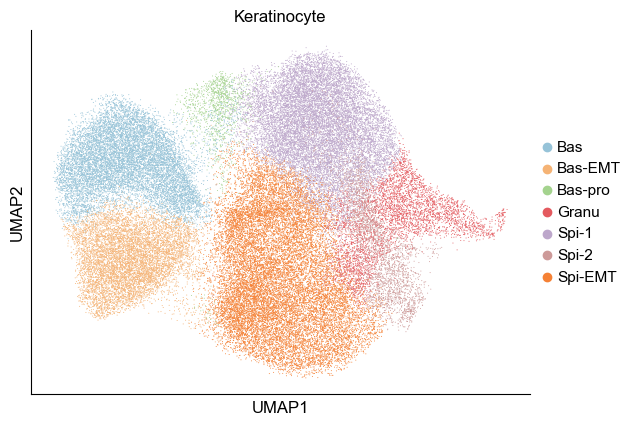

In [5]:
fig,ax = plt.subplots()
sc.pl.embedding(adata,"umap",color=["CellType2"],ax=ax,show=False,size=2.)
plt.title("Keratinocyte")
fig.savefig("2.3.Fgirue2A.pdf",format="pdf",bbox_inches="tight")
plt.show()

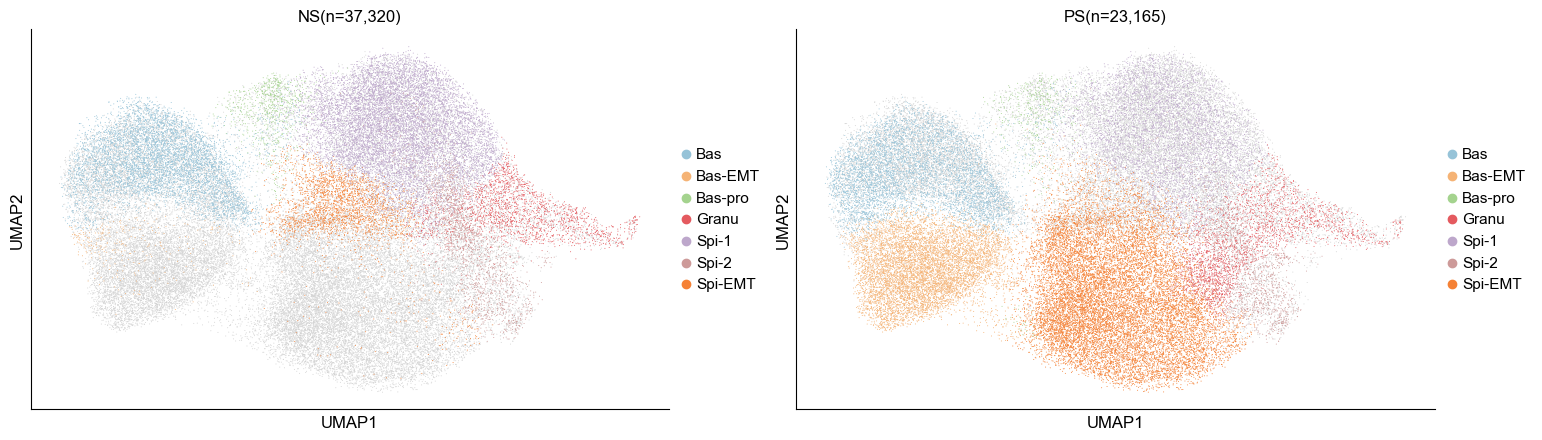

In [6]:
fig,axs = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(18)

sc.pl.embedding(adata[adata.obs['condition']!="NS"],"umap",ax=axs[0],show=False,size=2.,title=None)
sc.pl.embedding(adata[adata.obs['condition']=="NS"],"umap",color=["CellType2"],ax=axs[0],show=False,size=2.,title=None)
axs[0].set_title("NS(n=37,320)")

sc.pl.embedding(adata[adata.obs['condition']!="Scar/keloid"],"umap",ax=axs[1],show=False,size=2.,title=None)
sc.pl.embedding(adata[adata.obs['condition']=="Scar/keloid"],"umap",color=["CellType2"],ax=axs[1],show=False,size=2.,title=None)
axs[1].set_title("PS(n=23,165)")

fig.savefig("2.3.FigureS2A.pdf",format="pdf",bbox_inches="tight")
fig.show()

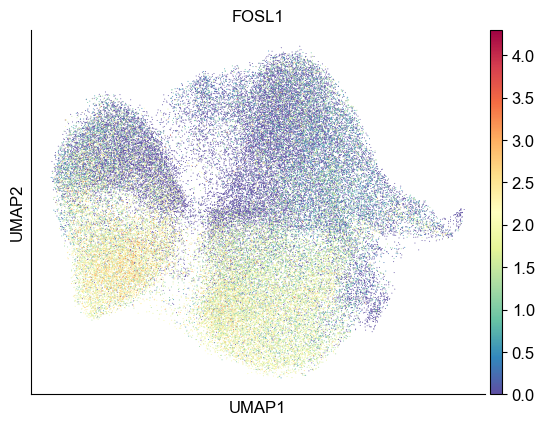

In [7]:
fig,ax = plt.subplots()
sc.pl.embedding(adata,"umap",color="FOSL1",ax=ax,show=False,size=2.)
fig.savefig("./2.3.FigureS2E.pdf",format="pdf",bbox_inches="tight")
plt.show()

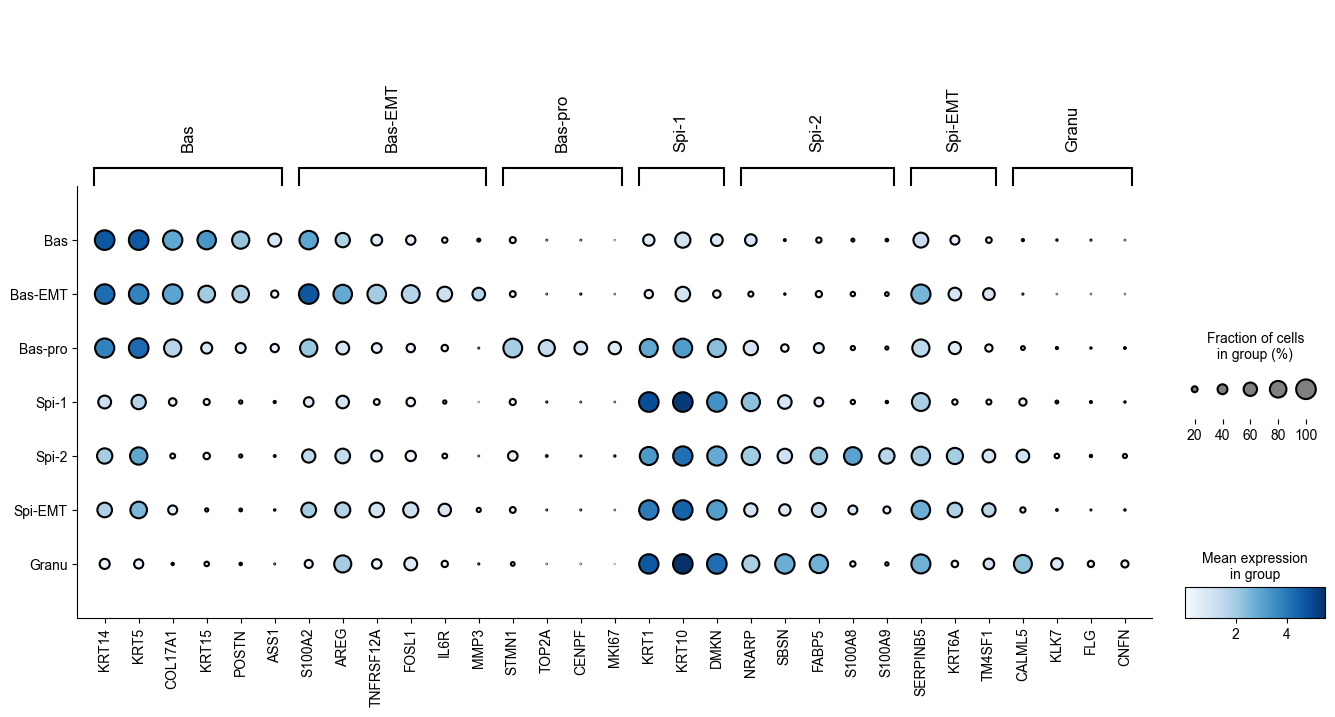

In [8]:
markers2 = {"Bas":['KRT14',"KRT5",'COL17A1','KRT15','POSTN','ASS1'],"Bas-EMT":["S100A2","AREG","TNFRSF12A","FOSL1","IL6R","MMP3"],"Bas-pro":["STMN1","TOP2A","CENPF","MKI67"],"Spi-1":["KRT1","KRT10","DMKN"],"Spi-2":["NRARP","SBSN","FABP5","S100A8","S100A9"],"Spi-EMT":["SERPINB5","KRT6A","TM4SF1"],"Granu":["CALML5","KLK7","FLG","CNFN"]}
categories_order = ["Bas","Bas-EMT","Bas-pro","Spi-1","Spi-2","Spi-EMT","Granu"]
fig,ax = plt.subplots()
fig.set_figheight(8)
fig.set_figwidth(16)
sc.pl.dotplot(adata,markers2,groupby="CellType2",cmap="Blues",ax=ax,show=False,categories_order=categories_order,linewidth=1.5)
fig.savefig("2.3..Figure2B.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [9]:
tmp = myutils.tl.calculate_cell_fraction(adata,group_by="CellType2",sample_key="condition")
#tmp = pd.melt(tmp.iloc[:,:-1],id_vars="condition")
tmp

,Bas,Bas-EMT,Bas-pro,Granu,Spi-1,Spi-2,Spi-EMT,condition,n_cells
0,0.265098,0.012562,0.031081,0.082322,0.420635,0.072739,0.115562,NS,23165
1,0.147401,0.208628,0.012353,0.066559,0.109780,0.038103,0.417176,Scar/keloid,37320


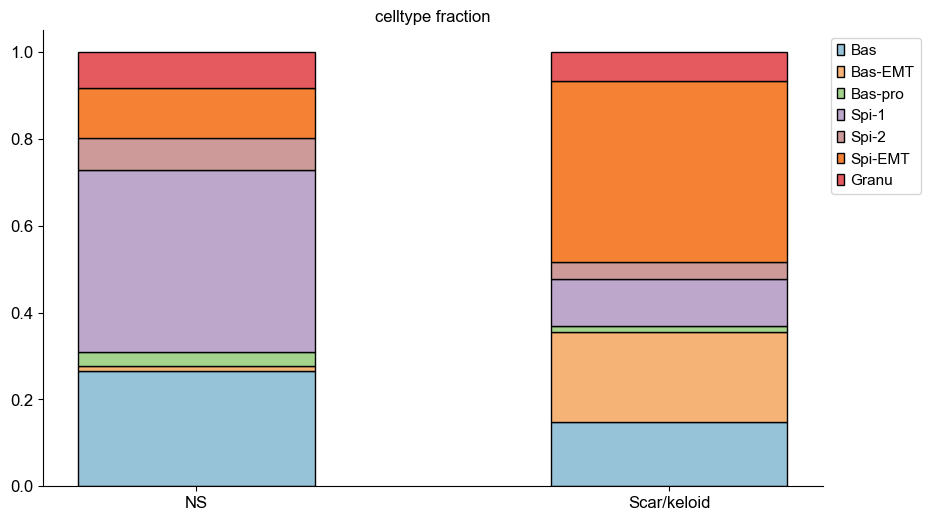

In [10]:
condition = tmp["condition"].tolist()
#colors_list = np.array(['#1f77b4','#ff7f0e','#279e68','#aa40fc','#8c564b','#e377c2','#b5bd61','#17becf','#d62728'])
#colors_list = np.array(['#96C3D8', '#F5B375', '#67A59B', '#E45A5F', '#BDA7CB','#9983B7', '#DD4B52', '#F58135','#4A9D47'])
colors_list=np.array(['#96C3D8', '#F5B375', '#A4D38E', '#BDA7CB', '#CD9A99','#F58135','#E45A5F'])
celltypes = ["Bas","Bas-EMT","Bas-pro","Spi-1","Spi-2","Spi-EMT","Granu"]

heights = {}
for celltype in celltypes:
    heights[celltype] = tmp[celltype].to_numpy()
    
colors = {}
for i, celltype in enumerate(celltypes):
    colors[celltype] = colors_list[i]

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(condition))
fig.set_figheight(6)
fig.set_figwidth(10)
for celltype, height in heights.items():
    p = ax.bar(condition, height, width, label=celltype, bottom=bottom,facecolor=colors[celltype],linewidth=1.,edgecolor="black")
    bottom += height

ax.set_title("celltype fraction")
ax.grid(False)
ax.legend(bbox_to_anchor=(1.0, 1.0))
fig.savefig("2.3.Figure2C.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [11]:
tmp = myutils.tl.calculate_cell_fraction(adata,group_by="CellType2",sample_key="condition_final")
tmp2 = myutils.tl.calculate_cell_fraction(adata,group_by="CellType2",sample_key="sample",condition_key="condition_final")
tmp.head(3)

,Bas,Bas-EMT,Bas-pro,Granu,Spi-1,Spi-2,Spi-EMT,condition_final,n_cells
0,0.265078,0.062986,0.028696,0.078307,0.277967,0.091804,0.195161,Hypertrophic Scar,8224
1,0.114139,0.249794,0.007733,0.063239,0.062242,0.022924,0.479929,Keloid,29096
2,0.265098,0.012562,0.031081,0.082322,0.420635,0.072739,0.115562,Normal Skin,23165


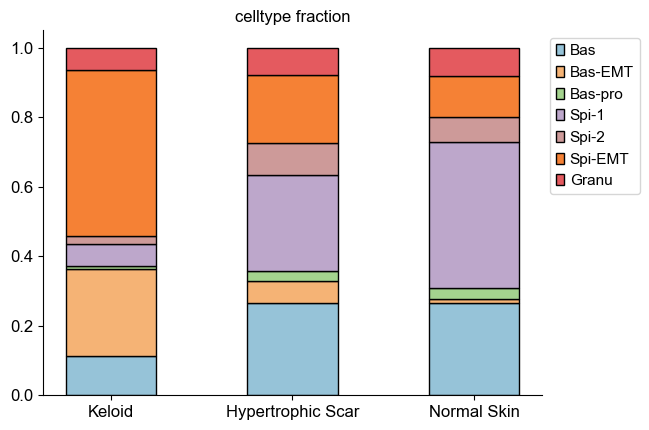

In [12]:
condition = ("Keloid","Hypertrophic Scar","Normal Skin")
tmp.index = tmp['condition_final']
tmp = tmp.loc[condition,:]

colors_list=np.array(['#96C3D8', '#F5B375', '#A4D38E', '#BDA7CB', '#CD9A99','#F58135','#E45A5F'])
celltypes = ["Bas","Bas-EMT","Bas-pro","Spi-1","Spi-2","Spi-EMT","Granu"]

heights = {}
for celltype in celltypes:
    heights[celltype] = tmp[celltype].to_numpy()
    
colors = {}
for i, celltype in enumerate(celltypes):
    colors[celltype] = colors_list[i]

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(condition))

for celltype, height in heights.items():
    p = ax.bar(condition, height, width, label=celltype, bottom=bottom,facecolor=colors[celltype],linewidth=1.,edgecolor="black")
    bottom += height
ax.grid(False)
ax.set_title("celltype fraction")
ax.legend(bbox_to_anchor=(1.0, 1.0))
fig.savefig("2.3.FigureS2B.pdf",format="pdf",bbox_inches="tight")
plt.show()

# Enrichment analysis

In [13]:
markers = myutils.tl.scanpy_ranking_genes(adata,group_by="CellType2",calculate_average_expression=False)
markers

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


,Bas_names,Bas_scores,Bas_pvals_adj,Bas_logfoldchanges,Bas-EMT_names,Bas-EMT_scores,Bas-EMT_pvals_adj,Bas-EMT_logfoldchanges,Bas-pro_names,Bas-pro_scores,...,Spi-1_pvals_adj,Spi-1_logfoldchanges,Spi-2_names,Spi-2_scores,Spi-2_pvals_adj,Spi-2_logfoldchanges,Spi-EMT_names,Spi-EMT_scores,Spi-EMT_pvals_adj,Spi-EMT_logfoldchanges
0,KRT14,260.728302,0.0,4.146216,COL17A1,223.122406,0.0,3.506596,TUBA1B,109.476921,...,0.0,3.553751,S100A8,89.782486,0.0,5.280905,FAM83C,120.090706,0.0,2.580271
1,COL17A1,235.781525,0.0,3.684206,S100A2,220.416458,0.0,4.641038,HMGB1,97.410164,...,0.0,3.301042,HSPA1A,72.321907,0.0,2.183957,DMKN,103.952209,0.0,1.647896
2,KRT5,218.069092,0.0,3.381174,KRT14,160.855301,0.0,3.032153,HMGB2,81.569992,...,0.0,1.993633,HSPA1B,67.921112,0.0,2.087369,S100A11,101.090446,0.0,1.255506
3,KRT15,207.421341,0.0,5.450264,TNFRSF12A,141.719559,0.0,2.772365,STMN1,74.473053,...,0.0,2.909761,JUN,62.096931,0.0,2.072204,KRT6A,100.342552,0.0,2.666788
4,CXCL14,194.473831,0.0,3.180666,DST,137.922958,0.0,3.437433,PTMA,70.771629,...,0.0,2.316534,DNAJB1,59.863274,0.0,1.498270,CLDN1,99.160225,0.0,1.868589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25993,LYPD3,-190.352188,0.0,-3.853753,TMEM99,-181.543793,0.0,-4.213587,MMP1,-41.776707,...,0.0,-2.822890,BGN,-82.912308,0.0,-3.709533,EGR1,-143.892929,0.0,-2.645885
25994,DMKN,-196.433792,0.0,-3.778714,KRTDAP,-210.792328,0.0,-5.614983,HAS3,-42.188473,...,0.0,-3.814829,DST,-84.049126,0.0,-3.038615,KRT15,-148.463959,0.0,-4.763410
25995,KRTDAP,-199.981400,0.0,-4.806240,KRT10,-230.520630,0.0,-4.944810,SDCBP2,-42.637676,...,0.0,-2.949181,TGFBI,-87.109566,0.0,-3.157480,FOSB,-149.152573,0.0,-2.845005
25996,KRT1,-248.778381,0.0,-5.203815,DMKN,-247.895874,0.0,-5.061123,SPRR1B,-45.524269,...,0.0,-3.364531,POSTN,-103.422821,0.0,-4.153759,ATF3,-171.073914,0.0,-3.330604


In [14]:
import decoupler as dc

In [15]:
msigdb = dc.read_gmt("../../../Data/msigdb_v2024.1.Hs_GMTs/c5.go.bp.v2024.1.Hs.symbols.gmt")
msigdb = msigdb[~msigdb.duplicated(['source',"target"])]
tmp = []
for i in msigdb['source']:
    if "_" in i:
        tmp.append(i[:i.find("_")])
    else:
        tmp.append(i)
msigdb['collection']=tmp
print(msigdb['collection'].unique().tolist())

['GOBP']


In [16]:
msigdb.head(3)

,source,target,collection
0,GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,AASDHPPT,GOBP
1,GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,ALDH1L1,GOBP
2,GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,ALDH1L2,GOBP


In [17]:
enr_pvals = dc.get_ora_df(
    df=markers['Bas-EMT_names'].head(200).tolist(),
    net=msigdb, 
    source='source',
    target='target',
)
enr_pvals = enr_pvals.sort_values("FDR p-value",ascending=True)
enr_pvals["-log10 p-value"] = - np.log10(enr_pvals['p-value'])
enr_pvals['Term2'] = [i.replace("GOBP_", "") for i in enr_pvals['Term']]
enr_pvals['Term2'] = [i.replace("_", " ") for i in enr_pvals['Term2']]
enr_pvals['Term2'] = [i.lower() for i in enr_pvals['Term2']]

In [18]:
use_paths = ["actin filament bundle organization", "cell adhesion","wound healing","cell cell adhesion","epithelium development","cytoskeleton organization","osteoblast differentiation","cell matrix adhesion","epithelial cell differentiation","ribosome biogenesis","positive regulation of epithelial cell migration","positive regulation of cytokine production","response to cytokine"]
Bas = enr_pvals[["Term2","-log10 p-value"]]
Bas = Bas.loc[Bas["Term2"].isin(use_paths)]
Bas['CellType'] = "Bas-EMT"
Bas

,Term2,-log10 p-value,CellType
5,actin filament bundle organization,8.744539,Bas-EMT
2868,wound healing,7.809507,Bas-EMT
284,cell adhesion,7.217546,Bas-EMT
389,cytoskeleton organization,7.345539,Bas-EMT
533,epithelium development,6.655409,Bas-EMT
287,cell cell adhesion,5.257040,Bas-EMT
1418,osteoblast differentiation,4.878446,Bas-EMT
525,epithelial cell differentiation,4.642193,Bas-EMT
313,cell matrix adhesion,4.487287,Bas-EMT
2525,response to cytokine,2.776325,Bas-EMT


In [19]:
enr_pvals = dc.get_ora_df(
    df=markers['Spi-EMT_names'].head(200).tolist(),
    net=msigdb, 
    source='source',
    target='target',
)
enr_pvals = enr_pvals.sort_values("FDR p-value",ascending=True)
enr_pvals["-log10 p-value"] = - np.log10(enr_pvals['p-value'])
enr_pvals['Term2'] = [i.replace("GOBP_", "") for i in enr_pvals['Term']]
enr_pvals['Term2'] = [i.replace("_", " ") for i in enr_pvals['Term2']]
enr_pvals['Term2'] = [i.lower() for i in enr_pvals['Term2']]

In [20]:
use_paths = ["actin filament bundle organization", "cell adhesion","wound healing","cell cell adhesion","epithelium development","cytoskeleton organization","osteoblast differentiation","cell matrix adhesion","epithelial cell differentiation","ribosome biogenesis","positive regulation of epithelial cell migration","positive regulation of cytokine production","response to cytokine"]
Spi = enr_pvals[["Term2","-log10 p-value"]]
Spi = Spi.loc[Spi["Term2"].isin(use_paths)]
Spi['CellType'] = 'Spi-EMT'
Spi

,Term2,-log10 p-value,CellType
2311,ribosome biogenesis,11.913758,Spi-EMT
452,epithelial cell differentiation,4.149886,Spi-EMT
457,epithelium development,3.963662,Spi-EMT
2552,wound healing,2.834345,Spi-EMT
341,cytoskeleton organization,1.742308,Spi-EMT
233,cell cell adhesion,1.171076,Spi-EMT
1241,osteoblast differentiation,1.321213,Spi-EMT
230,cell adhesion,0.855765,Spi-EMT
256,cell matrix adhesion,0.653695,Spi-EMT
1360,positive regulation of cytokine production,0.407656,Spi-EMT


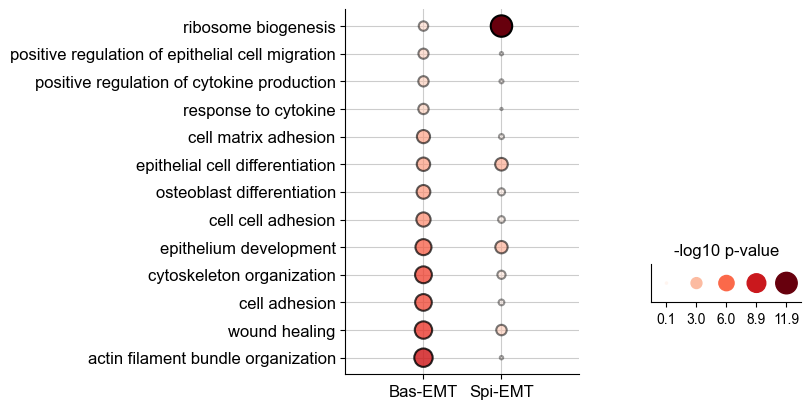

In [21]:
data = pd.concat((Bas,Spi))
alpha = (data['-log10 p-value']/data['-log10 p-value'].max()).to_numpy() + 0.6
alpha = alpha/alpha.max()
data['dot_size'] = data['-log10 p-value']*20
fig,ax = plt.subplots()
fig.set_figwidth(3)
ax.set_xlim(-1,2)
ax.set_xlabel("")
ax.scatter(x=data['CellType'],y=data["Term2"],s=data['dot_size'],c=data['dot_size'],cmap="Reds",alpha=alpha,linewidth=1.5,edgecolors="black")

ax2 = fig.add_axes([1.2,0.3,0.5,0.08])
diff = data['dot_size'].max() - data['dot_size'].min()
step = diff/4
size_range = np.arange(data['dot_size'].max(), data['dot_size'].min(), step * -1)[::-1].tolist()
size_range = [float(data['dot_size'].min())] + size_range 
ax2.scatter(x=np.arange(len(size_range))+0.5,y=np.zeros(len(size_range)),s=size_range,c=size_range,cmap="Reds")
ax2.grid(False)
ax2.set_xticks(np.arange(len(size_range)) + 0.5)
diff = data['-log10 p-value'].max() - data['-log10 p-value'].min()
step = diff/4
labels = np.arange(data['-log10 p-value'].max(), data['-log10 p-value'].min(), step * -1)[::-1].tolist()
labels = [float(data['-log10 p-value'].min())] + labels
labels = [str(i)[:str(i).find(".")+2] for i in labels]
ax2.set_xticklabels(labels, fontsize="small")
ax2.set_ylim(-0.1,0.1)
ax2.tick_params(axis="y", left=False, labelleft=False, labelright=False)
ax2.set_title("-log10 p-value")
ax2.set_xlim(0,5)
fig.savefig("2.3.Figure2E.pdf",format="pdf",bbox_inches="tight")
fig.show()

In [22]:
msigdb = dc.read_gmt("../../../Data/msigdb_v2024.1.Hs_GMTs/h.all.v2024.1.Hs.symbols.gmt")
msigdb = msigdb[~msigdb.duplicated(['source',"target"])]
tmp = []
for i in msigdb['source']:
    if "_" in i:
        tmp.append(i[:i.find("_")])
    else:
        tmp.append(i)
msigdb['collection']=tmp
print(msigdb['collection'].unique().tolist())

['HALLMARK']


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


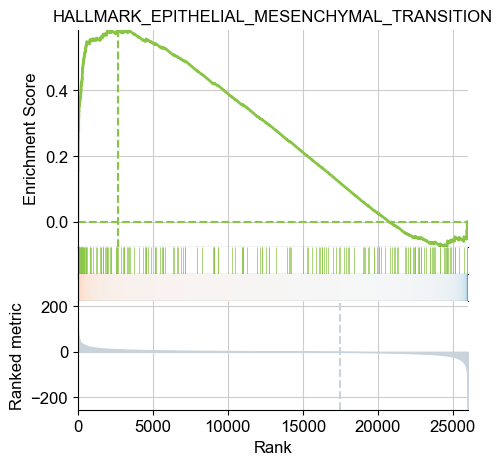

In [23]:
markers = myutils.tl.scanpy_ranking_genes(adata,group_by="CellType2")
markers.index = markers['Bas-EMT_names']
dc.plot_running_score(
    df=markers,
    stat='Bas-EMT_scores',
    net=msigdb,
    source='source',
    target='target',
    set_name="HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION", save="./2.3.FigureS2E.pdf")

# EMT_score

In [24]:
#The biomarkers associated with epithelialmesenchymal transition in human keloids(2024)
EMT_genes = pd.read_csv("keloid_KC_EMT.csv")
EMT_genes = EMT_genes[EMT_genes["change"]=="up"]['symbol'].tolist()
print(len(EMT_genes))

59


In [25]:
sc.tl.score_genes(adata,gene_list=EMT_genes,score_name="EMT_score")

computing score 'EMT_score'
    finished: added
    'EMT_score', score of gene set (adata.obs).
    1045 total control genes are used. (0:00:01)


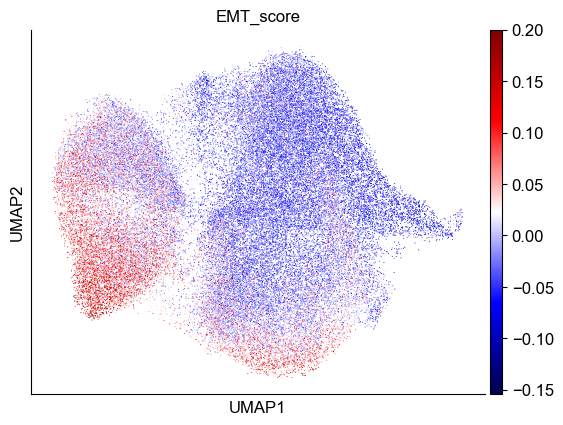

In [26]:
fig,ax = plt.subplots()
sc.pl.embedding(adata,"umap",color="EMT_score",ax=ax,vmax=0.2,show=False,cmap="seismic",size=2.)
plt.title("EMT_score")
fig.savefig("2.3.FgirueS2D.pdf",format="pdf",bbox_inches="tight")
plt.show()

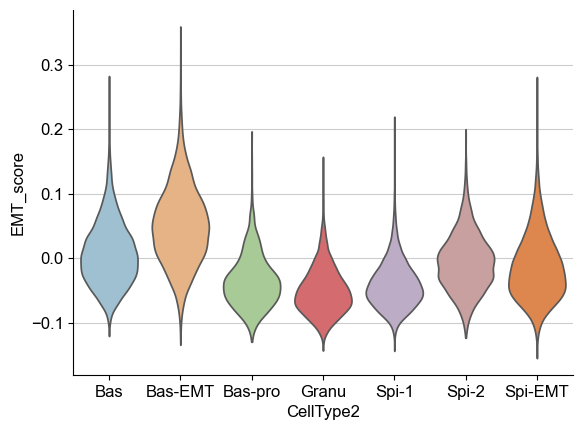

In [27]:
fig,ax = plt.subplots()
sc.pl.violin(adata,keys="EMT_score",groupby="CellType2",stripplot=False,show=False,ax=ax)
fig.savefig("2.3.Fgirue2F.pdf",format="pdf",bbox_inches="tight")
plt.show()

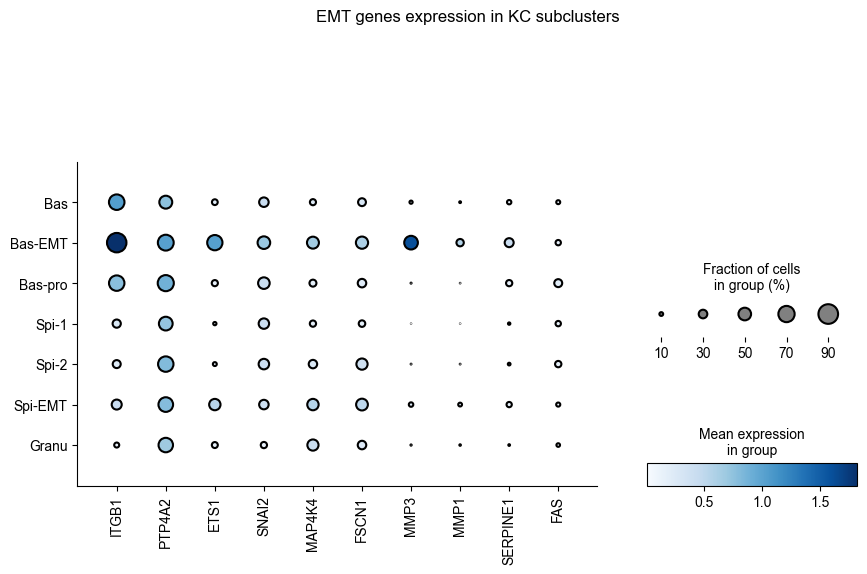

In [28]:
use_genes = ["ITGB1","PTP4A2","ETS1","SNAI2","MAP4K4","FSCN1","MMP3","MMP1","SERPINE1","FAS"]
categories_order = ["Bas","Bas-EMT","Bas-pro","Spi-1","Spi-2","Spi-EMT","Granu"]
fig,ax = plt.subplots()
fig.set_figheight(6)
fig.set_figwidth(10)
sc.pl.dotplot(adata,use_genes,groupby="CellType2",cmap="Blues",ax=ax,show=False,categories_order=categories_order,linewidth=1.5)
ax.set_title("EMT genes expression in KC subclusters")
fig.savefig("2.3.Figure2G.pdf",format="pdf",bbox_inches="tight")

# scenic

In [29]:
import loompy as lp

In [50]:
lf = lp.connect("2.2.scenic_result.loom",mode="r+",validate=False)
auc_mtx = pd.DataFrame( lf.ca.RegulonsAUC, index=lf.ca.CellID)
auc_mtx = sc.AnnData(auc_mtx)
lf.close()

In [56]:
auc_mtx.obsm = adata[auc_mtx.obs_names].obsm
auc_mtx.obs = adata[auc_mtx.obs_names].obs

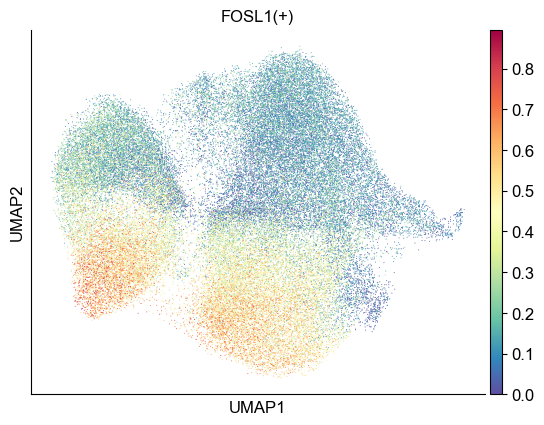

In [57]:
sc.pl.umap(auc_mtx,color="FOSL1(+)")

In [58]:
sc.pp.scale(auc_mtx)

In [59]:
auc_mtx.uns['log1p'] = {}
markers = myutils.tl.scanpy_ranking_genes(auc_mtx,group_by="CellType2",calculate_average_expression=True,save="tmp.csv")
markers.head(5)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


,Bas_names,Bas_scores,Bas_pvals_adj,Bas_logfoldchanges,Bas_expr,Bas-EMT_names,Bas-EMT_scores,Bas-EMT_pvals_adj,Bas-EMT_logfoldchanges,Bas-EMT_expr,...,Spi-2_names,Spi-2_scores,Spi-2_pvals_adj,Spi-2_logfoldchanges,Spi-2_expr,Spi-EMT_names,Spi-EMT_scores,Spi-EMT_pvals_adj,Spi-EMT_logfoldchanges,Spi-EMT_expr
0,ERF(+),143.818604,0.0,NaN,1.080597,ZNF281(+),187.602524,0.0,NaN,1.733986,...,ARNTL2(+),81.254524,0.0,NaN,1.530628,ZBTB44(+),113.900742,0.0,NaN,0.683816
1,ZBTB10(+),132.335281,0.0,NaN,1.024734,SMAD3(+),170.613052,0.0,NaN,1.533994,...,EGR2(+),72.523109,0.0,NaN,1.413003,MAX(+),106.601570,0.0,NaN,0.637471
2,TP73(+),124.592117,0.0,NaN,1.303389,ELK3(+),161.495041,0.0,NaN,1.426239,...,SREBF2(+),50.591164,0.0,NaN,0.831730,ZNF770(+),98.063171,0.0,NaN,0.602665
3,NFE2L1(+),112.449661,0.0,NaN,0.966205,ETS1(+),156.717758,0.0,NaN,1.217536,...,ATF6(+),47.911583,0.0,NaN,0.853959,KLF3(+),97.415535,0.0,NaN,0.611068
4,NFIC(+),111.441490,0.0,NaN,1.057806,FOXO3(+),136.813843,0.0,NaN,1.308392,...,SOX9(+),47.641727,0.0,NaN,1.238214,MAFK(+),94.595161,0.0,NaN,0.567285


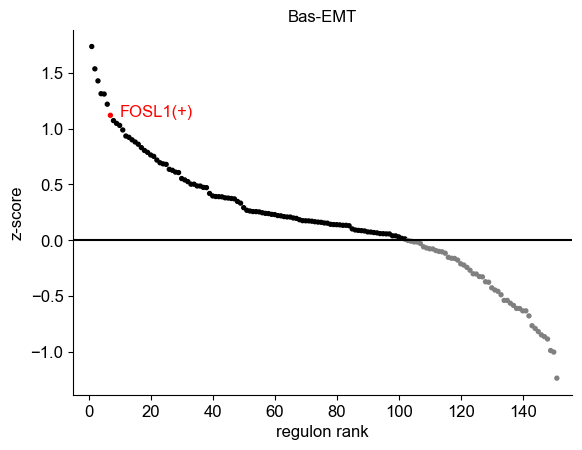

In [61]:
tmp = markers.loc[:,["Bas-EMT_names","Bas-EMT_expr"]]
tmp = tmp.loc[tmp['Bas-EMT_expr'].argsort()[::-1]]
tmp['rank'] = list(range(1,tmp.shape[0]+1))
tmp['color'] = "black"
tmp.loc[tmp['Bas-EMT_expr']<=0,"color"] = "grey"
tmp.loc[tmp['Bas-EMT_names']=="FOSL1(+)","color"] = "red"
fig,ax = plt.subplots()
ax.text(x=10,y=1.11,s="FOSL1(+)",c="red")
ax.scatter(tmp['rank'],tmp['Bas-EMT_expr'],s=8.,c=tmp['color'])
ax.hlines(xmin=-5,xmax=tmp.shape[0]+5,y=0,colors="black")
ax.set_xlim(-5,tmp.shape[0]+5)
ax.set_ylabel("z-score")
ax.set_xlabel("regulon rank")
ax.set_title("Bas-EMT")
ax.grid(False)
fig.savefig("2.2.Figure2I_rank.pdf",format="pdf",bbox_inches="tight")
fig.show()

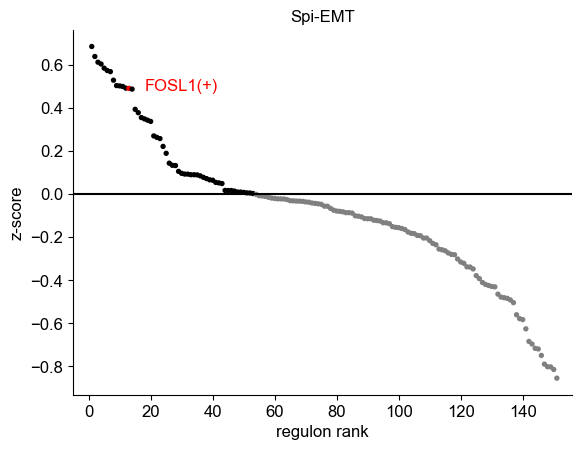

In [62]:
tmp = markers.loc[:,["Spi-EMT_names","Spi-EMT_expr"]]
tmp = tmp.loc[tmp['Spi-EMT_expr'].argsort()[::-1]]
tmp['rank'] = list(range(1,tmp.shape[0]+1))
tmp['color'] = "black"
tmp.loc[tmp['Spi-EMT_expr']<=0,"color"] = "grey"
tmp.loc[tmp['Spi-EMT_names']=="FOSL1(+)","color"] = "red"
fig,ax = plt.subplots()
ax.text(x=18,y=0.48,s="FOSL1(+)",c="red")
ax.scatter(tmp['rank'],tmp['Spi-EMT_expr'],s=8.,c=tmp['color'])
ax.hlines(xmin=-5,xmax=tmp.shape[0]+5,y=0,colors="black")
ax.set_xlim(-5,tmp.shape[0]+5)
ax.set_ylabel("z-score")
ax.set_xlabel("regulon rank")
ax.set_title("Spi-EMT")
ax.grid(False)
fig.savefig("2.2.FigureS2F.pdf",format="pdf",bbox_inches="tight")
fig.show()

In [63]:
adjs = pd.read_csv("2.2.adj.sample.tsv",sep="\t")
adjs = adjs[adjs["TF"] == "FOSL1"]
adjs = adjs.head(400)
adjs

,TF,target,importance
239,FOSL1,TNFRSF12A,185.902180
527,FOSL1,FHL2,139.052101
947,FOSL1,S100A2,109.719508
953,FOSL1,MAT2A,109.465857
1016,FOSL1,ETS1,106.651325
...,...,...,...
29242,FOSL1,TMEM70,25.630141
29474,FOSL1,AC015908.6,25.522839
29552,FOSL1,ITGA6,25.478107
29562,FOSL1,SCML1,25.473783


In [64]:
markers = myutils.tl.scanpy_ranking_genes(adata,group_by="CellType2")
markers

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:06)


,Bas_names,Bas_scores,Bas_pvals_adj,Bas_logfoldchanges,Bas-EMT_names,Bas-EMT_scores,Bas-EMT_pvals_adj,Bas-EMT_logfoldchanges,Bas-pro_names,Bas-pro_scores,...,Spi-1_pvals_adj,Spi-1_logfoldchanges,Spi-2_names,Spi-2_scores,Spi-2_pvals_adj,Spi-2_logfoldchanges,Spi-EMT_names,Spi-EMT_scores,Spi-EMT_pvals_adj,Spi-EMT_logfoldchanges
0,KRT14,260.728302,0.0,4.146216,COL17A1,223.122406,0.0,3.506596,TUBA1B,109.476921,...,0.0,3.553751,S100A8,89.782486,0.0,5.280905,FAM83C,120.090706,0.0,2.580271
1,COL17A1,235.781525,0.0,3.684206,S100A2,220.416458,0.0,4.641038,HMGB1,97.410164,...,0.0,3.301042,HSPA1A,72.321907,0.0,2.183957,DMKN,103.952209,0.0,1.647896
2,KRT5,218.069092,0.0,3.381174,KRT14,160.855301,0.0,3.032153,HMGB2,81.569992,...,0.0,1.993633,HSPA1B,67.921112,0.0,2.087369,S100A11,101.090446,0.0,1.255506
3,KRT15,207.421341,0.0,5.450264,TNFRSF12A,141.719559,0.0,2.772365,STMN1,74.473053,...,0.0,2.909761,JUN,62.096931,0.0,2.072204,KRT6A,100.342552,0.0,2.666788
4,CXCL14,194.473831,0.0,3.180666,DST,137.922958,0.0,3.437433,PTMA,70.771629,...,0.0,2.316534,DNAJB1,59.863274,0.0,1.498270,CLDN1,99.160225,0.0,1.868589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25993,LYPD3,-190.352188,0.0,-3.853753,TMEM99,-181.543793,0.0,-4.213587,MMP1,-41.776707,...,0.0,-2.822890,BGN,-82.912308,0.0,-3.709533,EGR1,-143.892929,0.0,-2.645885
25994,DMKN,-196.433792,0.0,-3.778714,KRTDAP,-210.792328,0.0,-5.614983,HAS3,-42.188473,...,0.0,-3.814829,DST,-84.049126,0.0,-3.038615,KRT15,-148.463959,0.0,-4.763410
25995,KRTDAP,-199.981400,0.0,-4.806240,KRT10,-230.520630,0.0,-4.944810,SDCBP2,-42.637676,...,0.0,-2.949181,TGFBI,-87.109566,0.0,-3.157480,FOSB,-149.152573,0.0,-2.845005
25996,KRT1,-248.778381,0.0,-5.203815,DMKN,-247.895874,0.0,-5.061123,SPRR1B,-45.524269,...,0.0,-3.364531,POSTN,-103.422821,0.0,-4.153759,ATF3,-171.073914,0.0,-3.330604


In [66]:
genes = markers["Bas-EMT_names"].head(200).tolist()
index = [i in genes for i in adjs['target']]
tmp = adjs.loc[index]
tmp['source'] = "Bas-EMT"
tmp.head(3)

,TF,target,importance,source
239,FOSL1,TNFRSF12A,185.902180,Bas-EMT
527,FOSL1,FHL2,139.052101,Bas-EMT
947,FOSL1,S100A2,109.719508,Bas-EMT


In [68]:
genes = markers["Spi-EMT_names"].head(200).tolist()
index = [i in genes for i in adjs['target']]
tmp2 = adjs.loc[index]
tmp2['source'] = "Spi-EMT"
tmp2.head(3)

,TF,target,importance,source
527,FOSL1,FHL2,139.052101,Spi-EMT
1032,FOSL1,LIMA1,106.263953,Spi-EMT
1267,FOSL1,GNL3,98.998376,Spi-EMT


In [70]:
# Figure2H data
intersect = np.intersect1d(tmp['target'],tmp2['target'])
tmp.loc[tmp['target'].isin(intersect),"source"] = "overlap"
tmp2 = tmp2[~tmp2['target'].isin(intersect)]
result = pd.concat((tmp,tmp2))
result.to_csv("2.2.scenic_for_cytoscape.tsv",sep="\t")
result

,TF,target,importance,source
239,FOSL1,TNFRSF12A,185.902180,Bas-EMT
527,FOSL1,FHL2,139.052101,overlap
947,FOSL1,S100A2,109.719508,Bas-EMT
953,FOSL1,MAT2A,109.465857,Bas-EMT
1016,FOSL1,ETS1,106.651325,Bas-EMT
...,...,...,...,...
22722,FOSL1,SERTAD2,29.416391,Spi-EMT
24890,FOSL1,LRRC8A,28.029696,Spi-EMT
24917,FOSL1,FAM110C,28.013896,Spi-EMT
25120,FOSL1,COPS2,27.879473,Spi-EMT


In [20]:
!conda list

# packages in environment at C:\Users\dell\.conda\envs\scanpy:
#
# Name                    Version                   Build  Channel
absl-py                   2.3.0                    pypi_0    pypi
adjusttext                1.3.0                    pypi_0    pypi
aiobotocore               2.5.4                    pypi_0    pypi
aiohappyeyeballs          2.6.1                    pypi_0    pypi
aiohttp                   3.12.4                   pypi_0    pypi
aioitertools              0.12.0                   pypi_0    pypi
aiosignal                 1.3.2                    pypi_0    pypi
anndata                   0.10.8                   pypi_0    pypi
anyio                     4.8.0                    pypi_0    pypi
argon2-cffi               23.1.0                   pypi_0    pypi
argon2-cffi-bindings      21.2.0                   pypi_0    pypi
array-api-compat          1.10.0                   pypi_0    pypi
arrow                     1.3.0                    pypi_0    pypi
asciitree 